In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


In [3]:
OUTPUT_DIR = Path(r'C:\Users\taylo\hyperwind_now\data\processed')
MODEL_DIR  = Path(r'C:\Users\taylo\hyperwind_now\models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IN_LEN     = 5
OUT_LEN    = 4
N_FEATURES = 66
BATCH_SIZE = 64
EPOCHS     = 30
LR         = 0.001
PATIENCE   = 7

print("Config ready!")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Model dir : {MODEL_DIR}")

Config ready!
Output dir: C:\Users\taylo\hyperwind_now\data\processed
Model dir : C:\Users\taylo\hyperwind_now\models


In [4]:
def load_all_monthly_data():
    all_files = sorted(OUTPUT_DIR.glob("hyperwind_module1_2*.csv"))
    
    dfs = []
    for f in all_files:
        df = pd.read_csv(f, index_col=0, parse_dates=True)
        dfs.append(df)
    
    df_all = pd.concat(dfs).sort_index()
    df_all = df_all[~df_all.index.duplicated(keep='first')]
    
    print(f"Total timesteps : {len(df_all)}")
    print(f"Period          : {df_all.index.min()} to {df_all.index.max()}")
    print(f"Features        : {df_all.shape[1]}")
    return df_all

df_all = load_all_monthly_data()

Total timesteps : 5289
Period          : 2020-01-01 00:00:00 to 2021-12-30 21:00:00
Features        : 66


In [5]:
def prepare_data(df):
    # Temporal split
    df_train = df[df.index <= "2021-06-30"]
    df_val   = df[(df.index >= "2021-07-01") & (df.index <= "2021-09-30")]
    df_test  = df[df.index >= "2021-10-01"]
    
    print(f"Train: {len(df_train)} timesteps "
          f"({df_train.index.min().date()} to {df_train.index.max().date()})")
    print(f"Val  : {len(df_val)} timesteps "
          f"({df_val.index.min().date()} to {df_val.index.max().date()})")
    print(f"Test : {len(df_test)} timesteps "
          f"({df_test.index.min().date()} to {df_test.index.max().date()})")
    
    # Normalize using TRAINING set only
    train_mean = df_train.mean()
    train_std  = df_train.std().replace(0, 1)
    
    df_train_n = (df_train - train_mean) / train_std
    df_val_n   = (df_val   - train_mean) / train_std
    df_test_n  = (df_test  - train_mean) / train_std
    
    df_train_n = df_train_n.fillna(0)
    df_val_n   = df_val_n.fillna(0)
    df_test_n  = df_test_n.fillna(0)
    
    # Save normalization stats
    train_mean.to_csv(MODEL_DIR / "normalization_mean.csv")
    train_std.to_csv(MODEL_DIR  / "normalization_std.csv")
    print("\nNormalization stats saved!")
    
    return df_train_n, df_val_n, df_test_n, train_mean, train_std

df_train_n, df_val_n, df_test_n, train_mean, train_std = prepare_data(df_all)

Train: 3875 timesteps (2020-01-01 to 2021-06-29)
Val  : 702 timesteps (2021-07-01 to 2021-09-29)
Test : 712 timesteps (2021-10-01 to 2021-12-30)

Normalization stats saved!


In [7]:
class WindSequenceDataset(Dataset):
    def __init__(self, df, in_len=IN_LEN, out_len=OUT_LEN):
        self.data       = torch.FloatTensor(df.values)
        self.in_len     = in_len
        self.out_len    = out_len
        self.target_col = df.columns.get_loc("ws10m_q050")
        n = len(df) - in_len - out_len + 1
        self.n_samples  = max(0, n)
        
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.in_len]
        y = self.data[idx + self.in_len :
                      idx + self.in_len + self.out_len,
                      self.target_col]
        return x, y

train_ds = WindSequenceDataset(df_train_n)
val_ds   = WindSequenceDataset(df_val_n)
test_ds  = WindSequenceDataset(df_test_n)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences : {len(train_ds)}")
print(f"Val sequences   : {len(val_ds)}")
print(f"Test sequences  : {len(test_ds)}")

x_sample, y_sample = train_ds[0]
print(f"\nInput shape  : {x_sample.shape}")
print(f"Target shape : {y_sample.shape}")

assert len(val_ds)  > 0, "Validation set is empty!"
assert len(test_ds) > 0, "Test set is empty!"
print("\nAll datasets ready for training!")

Train sequences : 3867
Val sequences   : 694
Test sequences  : 704

Input shape  : torch.Size([5, 66])
Target shape : torch.Size([4])

All datasets ready for training!


In [8]:
class TrajGRU(nn.Module):
    def __init__(self, n_features, hidden_size=128,
                 n_layers=2, out_len=OUT_LEN, dropout=0.2):
        super(TrajGRU, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )
        self.bn = nn.BatchNorm1d(hidden_size)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, out_len)
        )
        
    def forward(self, x):
        gru_out, _   = self.gru(x)
        last_hidden  = gru_out[:, -1, :]
        last_hidden  = self.bn(last_hidden)
        forecast     = self.fc(last_hidden)
        return forecast

model = TrajGRU(
    n_features=N_FEATURES,
    hidden_size=128,
    n_layers=2,
    out_len=OUT_LEN,
    dropout=0.2
).to(device)

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"Model ready! Trainable parameters: {n_params:,}")

Model ready! Trainable parameters: 183,108


In [11]:
def train_model(model, train_dl, val_dl,
                epochs=EPOCHS, patience=PATIENCE):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )
    
    best_val_loss    = float('inf')
    patience_counter = 0
    history          = {"train_loss": [], "val_loss": []}
    
    print(f"Training TrajGRU on {device}")
    print(f"Epochs: {epochs} | Patience: {patience}")
    print("-" * 55)
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Status':>10}")
    print("-" * 55)
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                pred = model(x_batch)
                loss = criterion(pred, y_batch)
                val_losses.append(loss.item())
        
        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(),
                       MODEL_DIR / "trajgru_best.pt")
            status = "SAVED"
        else:
            patience_counter += 1
            status = f"patience {patience_counter}/{patience}"
        
        print(f"{epoch+1:>6} {train_loss:>12.4f} "
              f"{val_loss:>10.4f} {status:>10}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    print("-" * 55)
    print(f"Best val loss: {best_val_loss:.4f}")
    print(f"Model saved to {MODEL_DIR / 'trajgru_best.pt'}")
    return history

history = train_model(model, train_dl, val_dl)

Training TrajGRU on cpu
Epochs: 30 | Patience: 7
-------------------------------------------------------
 Epoch   Train Loss   Val Loss     Status
-------------------------------------------------------
     1       0.6133     0.2928      SAVED
     2       0.5097     0.2826      SAVED
     3       0.4797     0.2977 patience 1/7
     4       0.4622     0.2983 patience 2/7
     5       0.4469     0.2485      SAVED
     6       0.4354     0.2645 patience 1/7
     7       0.4208     0.3178 patience 2/7
     8       0.4022     0.2463      SAVED
     9       0.3962     0.2454      SAVED
    10       0.3777     0.2851 patience 1/7
    11       0.3695     0.2419      SAVED
    12       0.3603     0.2606 patience 1/7
    13       0.3497     0.3127 patience 2/7
    14       0.3353     0.2843 patience 3/7
    15       0.3195     0.2596 patience 4/7
    16       0.3013     0.2687 patience 5/7
    17       0.2954     0.2705 patience 6/7
    18       0.2832     0.2580 patience 7/7

Early stopping a

In [12]:
# Load best model
model.load_state_dict(torch.load(MODEL_DIR / "trajgru_best.pt"))
model.eval()

# Get predictions on test set
all_preds  = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_dl:
        pred = model(x_batch.to(device))
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y_batch.numpy())

preds   = np.concatenate(all_preds,   axis=0)
targets = np.concatenate(all_targets, axis=0)

# Denormalize using training stats
ws_mean = train_mean["ws10m_q050"]
ws_std  = train_std["ws10m_q050"]

preds_real   = preds   * ws_std + ws_mean
targets_real = targets * ws_std + ws_mean

# Compute RMSE per forecast step
rmse_per_step = np.sqrt(np.mean((preds_real - targets_real)**2, axis=0))
hours_ahead   = [3, 6, 9, 12]

print("=== TrajGRU Forecast Skill ===")
print(f"{'Lead Time':>12} {'RMSE (m/s)':>12}")
print("-" * 26)
for h, rmse in zip(hours_ahead, rmse_per_step):
    print(f"{h:>10}h  {rmse:>10.3f}")

# Persistence baseline (just repeat last known wind speed)
x_last = np.array([
    test_ds[i][0][-1, test_ds.target_col].item()
    for i in range(len(test_ds))
])
x_last_real = x_last * ws_std + ws_mean

persist_rmse = np.array([
    np.sqrt(np.mean((x_last_real - targets_real[:, i])**2))
    for i in range(OUT_LEN)
])

print("\n=== Persistence Baseline ===")
print(f"{'Lead Time':>12} {'RMSE (m/s)':>12}")
print("-" * 26)
for h, rmse in zip(hours_ahead, persist_rmse):
    print(f"{h:>10}h  {rmse:>10.3f}")

# Skill score (how much better than persistence)
skill = 1 - (rmse_per_step / persist_rmse)
print("\n=== Skill Score vs Persistence ===")
print(f"{'Lead Time':>12} {'Skill':>10}")
print("-" * 24)
for h, s in zip(hours_ahead, skill):
    print(f"{h:>10}h  {s:>9.1%}")

=== TrajGRU Forecast Skill ===
   Lead Time   RMSE (m/s)
--------------------------
         3h       0.741
         6h       1.173
         9h       1.488
        12h       1.634

=== Persistence Baseline ===
   Lead Time   RMSE (m/s)
--------------------------
         3h       1.051
         6h       1.540
         9h       1.812
        12h       2.018

=== Skill Score vs Persistence ===
   Lead Time      Skill
------------------------
         3h      29.5%
         6h      23.9%
         9h      17.8%
        12h      19.0%


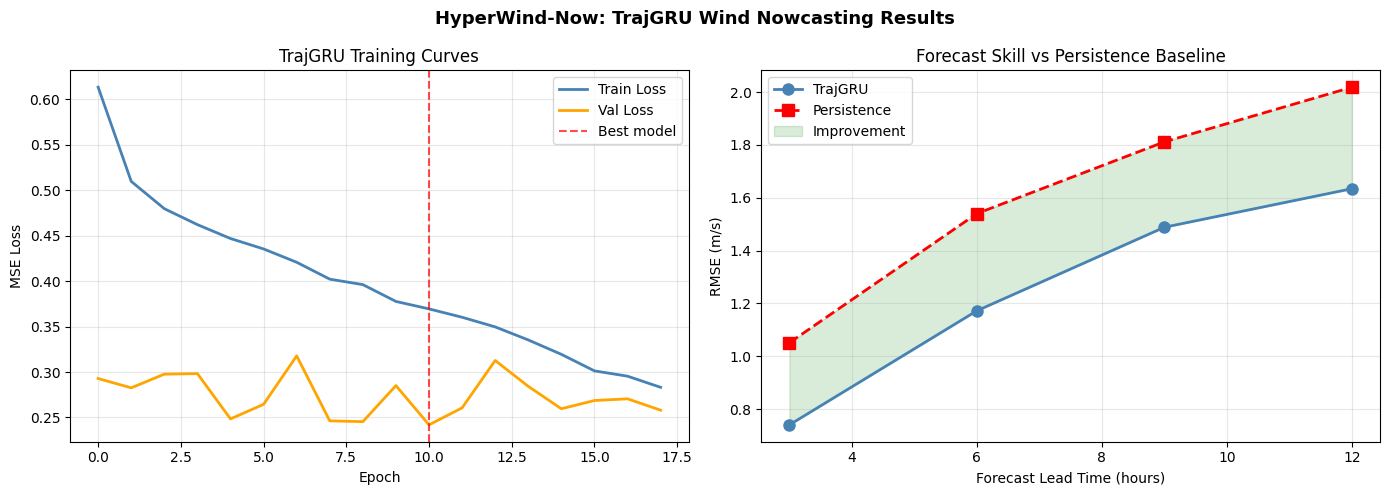

Results plot saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training curves
axes[0].plot(history["train_loss"], label="Train Loss",
             color="steelblue", linewidth=2)
axes[0].plot(history["val_loss"],   label="Val Loss",
             color="orange", linewidth=2)
axes[0].axvline(x=np.argmin(history["val_loss"]),
                color="red", linestyle="--", alpha=0.7,
                label="Best model")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("TrajGRU Training Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: RMSE vs lead time
axes[1].plot(hours_ahead, rmse_per_step,
             "o-", color="steelblue", linewidth=2,
             markersize=8, label="TrajGRU")
axes[1].plot(hours_ahead, persist_rmse,
             "s--", color="red", linewidth=2,
             markersize=8, label="Persistence")
axes[1].fill_between(hours_ahead, rmse_per_step, persist_rmse,
                     alpha=0.15, color="green",
                     label="Improvement")
axes[1].set_xlabel("Forecast Lead Time (hours)")
axes[1].set_ylabel("RMSE (m/s)")
axes[1].set_title("Forecast Skill vs Persistence Baseline")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("HyperWind-Now: TrajGRU Wind Nowcasting Results",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "trajgru_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Results plot saved!")

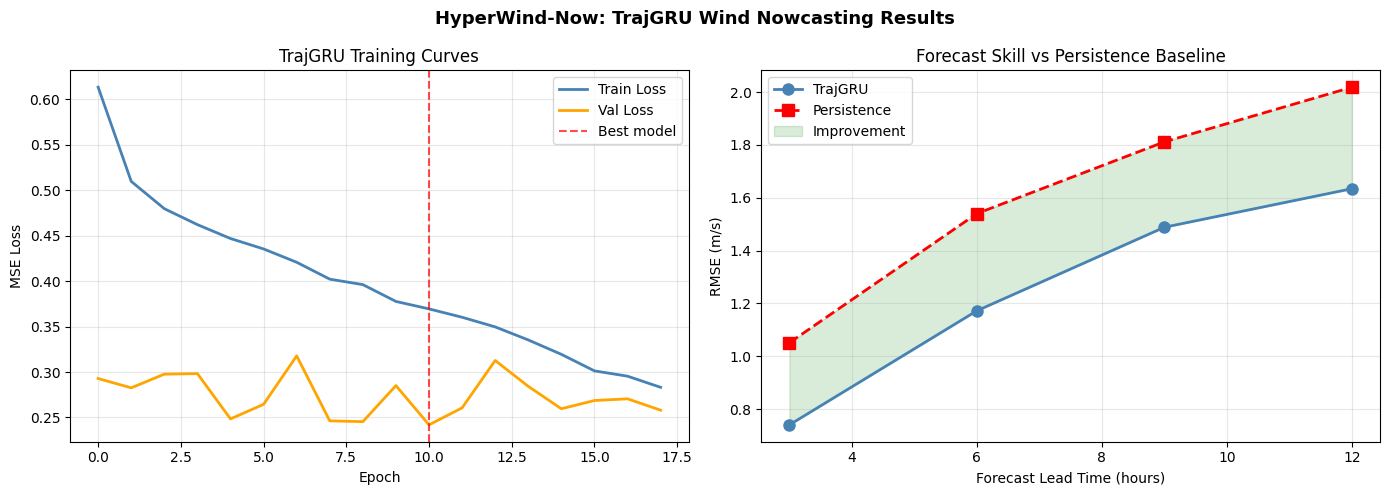

Results plot saved to: outputs\trajgru_results.png


In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ensure output directory exists
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training curves
axes[0].plot(history["train_loss"], label="Train Loss",
             color="steelblue", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss",
             color="orange", linewidth=2)

best_epoch = np.argmin(history["val_loss"])
axes[0].axvline(x=best_epoch,
                color="red", linestyle="--", alpha=0.7,
                label="Best model")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("TrajGRU Training Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: RMSE vs lead time
axes[1].plot(hours_ahead, rmse_per_step,
             "o-", color="steelblue", linewidth=2,
             markersize=8, label="TrajGRU")

axes[1].plot(hours_ahead, persist_rmse,
             "s--", color="red", linewidth=2,
             markersize=8, label="Persistence")

axes[1].fill_between(hours_ahead, rmse_per_step, persist_rmse,
                     alpha=0.15, color="green",
                     label="Improvement")

axes[1].set_xlabel("Forecast Lead Time (hours)")
axes[1].set_ylabel("RMSE (m/s)")
axes[1].set_title("Forecast Skill vs Persistence Baseline")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("HyperWind-Now: TrajGRU Wind Nowcasting Results",
             fontsize=13, fontweight="bold")

plt.tight_layout()

# Save figure
save_path = OUTPUT_DIR / "trajgru_results.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Results plot saved to: {save_path}")